In [2]:
## GRADIENT DESCENT

In [3]:
import numpy as np 
import tensorflow as tf
import time
import keras
#from keras import layers
import time
from sklearn.model_selection import train_test_split

2026-03-26 09:10:36.798482: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
import sys

module_path = "./"
sys.path.append(module_path)

import potentials as pot
import utils

In [5]:
def grad_norm_squared(V, x, non_zero, factor=1.0):
    n_vars = x.shape[1]
    mask = tf.constant([1.0 if i in non_zero else 0.0 for i in range(n_vars)], dtype=x.dtype)
    
    with tf.GradientTape() as tape:
        tape.watch(x) # differentiate with respect to x not x_masked
        x_masked = x * mask  
        y = V(x_masked)      # V évalué sur x tronqué

    gradients = tape.gradient(y, x)
    return factor * tf.reduce_sum(gradients**2, axis=1)

In [6]:
my_colors = [[0.1,0.3,0.45],[0.65,0.35,0],[0.5,0.0,0.13],[0.08,0.48,0.31],[0.75,0.36,0.51],[0.99,0.86,0.18],[1.0,0.84,0.64]]

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 20
})

In [7]:
non_zero = np.array([0,1,3,7,9])

# randomly initialize the points

n_points = 10000
x_5d = tf.Variable(4*np.random.rand(n_points, 13)-2, dtype=tf.float32)

history_5d = []
history_loss_5d = []

In [8]:
init_time = time.time()
alpha = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)

# Learning loop 
loss_prev_step=10**8

#update_alpha = False
update_opt = False
for step in range(2000):  
    with tf.GradientTape() as tape:       
        grad_norm_squared_this_step = grad_norm_squared(pot.V13d_sugra, x_5d, non_zero)
        loss = tf.reduce_sum(grad_norm_squared_this_step) # minimize ||∇V||^2 for all points
    
    
    # Compute ||∇V||^2 with respect to x
    gradients = tape.gradient(loss, [x_5d])

    if step in [250,500,750,1000]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha)
    elif step in [1250,1500,1750]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha/10)
    elif step in [6000]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha/100)
    
    # Apply gradient descent to all points
    optimizer.apply_gradients(zip(gradients, [x_5d]))
    
    history_5d.append(loss)
    history_loss_5d.append(optimizer.learning_rate.numpy())
    
    if step % 1 == 0:

        current_lr = optimizer.learning_rate.numpy()
        print(f"""Step {step}: ||∇V||^2 = {loss.numpy()} with learning rate {current_lr}""")
        
    if np.log(loss.numpy())/np.log(10)<-10: 
        print("Converged enough") 
        print(f"Step {step}: ||∇V||^2 = {loss.numpy()}")
        break

final_time = time.time()

hours = (final_time - init_time)//3600
minutes = ((final_time - init_time) - hours * 3600)//60
print(f"Total time {hours}h {minutes}m")


Step 0: ||∇V||^2 = 3134224640.0 with learning rate 0.0010000000474974513
Step 1: ||∇V||^2 = 3102427136.0 with learning rate 0.0010000000474974513
Step 2: ||∇V||^2 = 3070963200.0 with learning rate 0.0010000000474974513
Step 3: ||∇V||^2 = 3039833088.0 with learning rate 0.0010000000474974513
Step 4: ||∇V||^2 = 3009038336.0 with learning rate 0.0010000000474974513
Step 5: ||∇V||^2 = 2978580736.0 with learning rate 0.0010000000474974513
Step 6: ||∇V||^2 = 2948462592.0 with learning rate 0.0010000000474974513
Step 7: ||∇V||^2 = 2918684160.0 with learning rate 0.0010000000474974513
Step 8: ||∇V||^2 = 2889246720.0 with learning rate 0.0010000000474974513
Step 9: ||∇V||^2 = 2860151552.0 with learning rate 0.0010000000474974513
Step 10: ||∇V||^2 = 2831398400.0 with learning rate 0.0010000000474974513
Step 11: ||∇V||^2 = 2802988032.0 with learning rate 0.0010000000474974513
Step 12: ||∇V||^2 = 2774919680.0 with learning rate 0.0010000000474974513
Step 13: ||∇V||^2 = 2747193856.0 with learning r

KeyboardInterrupt: 

In [9]:
#np.save('Points_5d.npy',x_5d.numpy())

In [14]:
x_5d = np.load('Points_5d.npy')

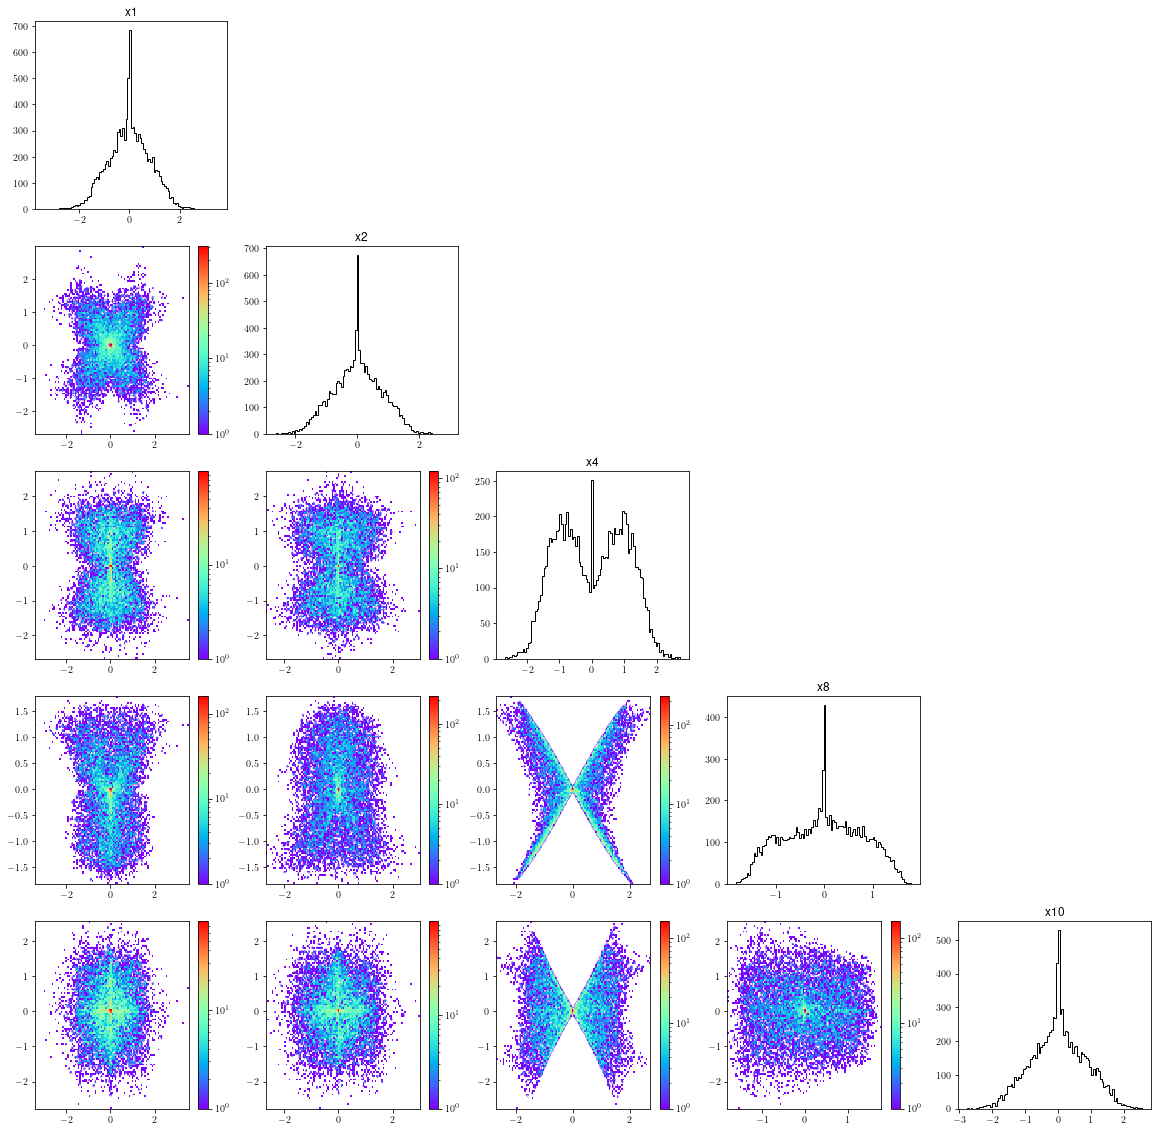

In [15]:
#utils.triangular_plot(x_5d.numpy()[:,non_zero],figsize=(20,20),names=['x1','x2','x4','x8','x10'])
utils.triangular_plot(x_5d,figsize=(20,20),names=['x1','x2','x4','x8','x10'])

In [16]:
## Local analysis

In [17]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from joblib import Parallel, delayed
from tqdm import tqdm
import time 

def local_dim_1_point(x, var_thres=0.99):
    """Calcule la dimension locale en utilisant PCA."""
    pca = PCA()
    pca.fit(x)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    return np.argmax(cumulative_variance >= var_thres) + 1

def compute_local_dim(i, data, neighbors_idx, var_thres, verbose):
    """Calcule la dimension locale pour un point donné."""
    local_neighbors = data[neighbors_idx[i]]
    dim = local_dim_1_point(local_neighbors, var_thres=var_thres)
    if verbose >= 2 and i % 100 == 0:
        print(f"Point {i}: Dimension locale estimée = {dim}")
    return [dim, i]

def local_dim_n_points(data, verbose=0, n_neig=20, var_thres=0.99, n_jobs=-1):
    """Calcule la dimension locale pour tous les points avec affichage de la progression."""
    n_points = data.shape[0]

    # Recherche des voisins avec KD-Tree
    if verbose >= 1:
        print("Recherche des voisins avec KD-Tree...")
    nbrs = NearestNeighbors(n_neighbors=n_neig, algorithm='kd_tree').fit(data)
    _, neighbors_idx = nbrs.kneighbors(data)

    # Calcul parallèle avec barre de progression
    if verbose >= 1:
        print("Calcul des dimensions locales...")
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_local_dim)(i, data, neighbors_idx, var_thres, verbose)
        for i in tqdm(range(n_points), desc="Progression", disable=(verbose <= 2))
    )
    
    #results = Parallel(n_jobs=n_jobs)(
    #    delayed(compute_local_dim)(i, data, neighbors_idx, var_thres, verbose)
    #    for i in range(n_points)
    #)
    
    if verbose >= 1:
        print("Calcul terminé !")
    
    return results


In [18]:
start = time.time()
loc_dim_diff_nneig = []
all_n_neig = [5,10,20,50]
#all_n_neig = [10]

for i in all_n_neig:
    print(i)
    loc_dim = local_dim_n_points(x_5d,
                             verbose=1,
                             n_neig=i,
                             n_jobs=4)
    loc_dim_diff_nneig.append(loc_dim)

end = time.time()

5
Recherche des voisins avec KD-Tree...
Calcul des dimensions locales...
Calcul terminé !
10
Recherche des voisins avec KD-Tree...
Calcul des dimensions locales...
Calcul terminé !
20
Recherche des voisins avec KD-Tree...
Calcul des dimensions locales...
Calcul terminé !
50
Recherche des voisins avec KD-Tree...
Calcul des dimensions locales...
Calcul terminé !


In [24]:
all_dim = []
for i in range(len(all_n_neig)):
    all_dim.append([np.sum(np.array(loc_dim_diff_nneig[i])[:,0]==k) for k in range(1,6)])

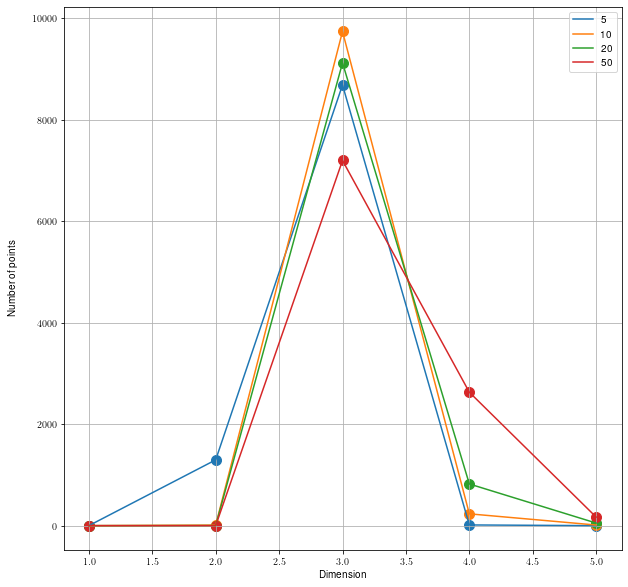

In [25]:
plt.figure(figsize=(10,10))
for i in range(len(all_n_neig)):
    plt.plot(range(1,6),np.array(all_dim[i]),label=str(all_n_neig[i]))#,color=my_colors[i-1])
    plt.scatter(range(1,6), np.array(all_dim[i]), s=100)#, color=my_colors[i-1])
plt.xlabel("Dimension")
plt.ylabel("Number of points",labelpad=15)
plt.legend()
plt.grid()
plt.show()

In [26]:
all_local_dim_5d = np.array(loc_dim_diff_nneig)[2][:,0] 


In [27]:
## Clustering 

In [31]:
from sklearn.cluster import HDBSCAN

In [32]:
x_5d_deco = x_5d[np.array(all_local_dim_5d)==3]

In [33]:
clusterer = HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(x_5d_deco)
data_labeled=x_5d_deco[labels!=-1] 

In [34]:
for lab_idx in range(np.max(labels)+2):
    print(x_5d_deco[labels==lab_idx-1].shape)

(1583, 5)
(7525, 5)
(17, 5)


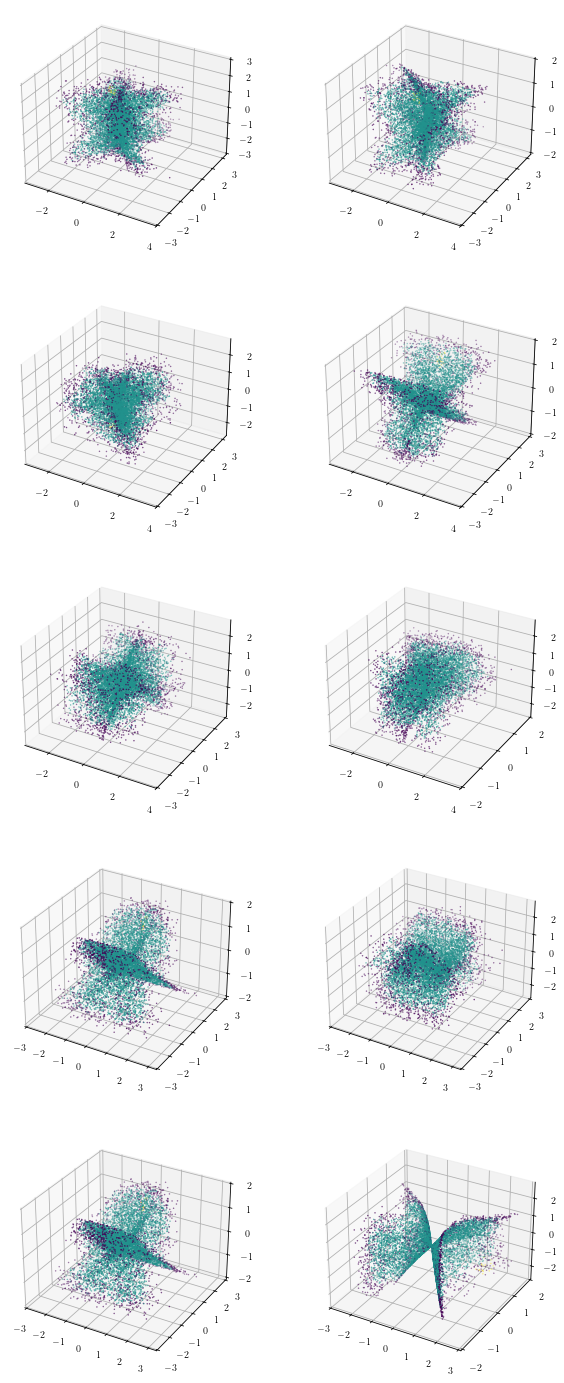

In [36]:
#%matplotlib widget 

fig, axes = plt.subplots(5, 2, subplot_kw={'projection': '3d'}, figsize=(10, 25))

axes[0,0].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,2],c=labels, cmap="viridis",s=0.2)
axes[0,1].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[1,0].scatter(x_5d_deco[:,0],x_5d_deco[:,1],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[1,1].scatter(x_5d_deco[:,0],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[2,0].scatter(x_5d_deco[:,0],x_5d_deco[:,2],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[2,1].scatter(x_5d_deco[:,0],x_5d_deco[:,3],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[3,0].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[3,1].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
axes[4,0].scatter(x_5d_deco[:,1],x_5d_deco[:,2],x_5d_deco[:,3],c=labels, cmap="viridis",s=0.2)
axes[4,1].scatter(x_5d_deco[:,2],x_5d_deco[:,3],x_5d_deco[:,4],c=labels, cmap="viridis",s=0.2)
plt.show()

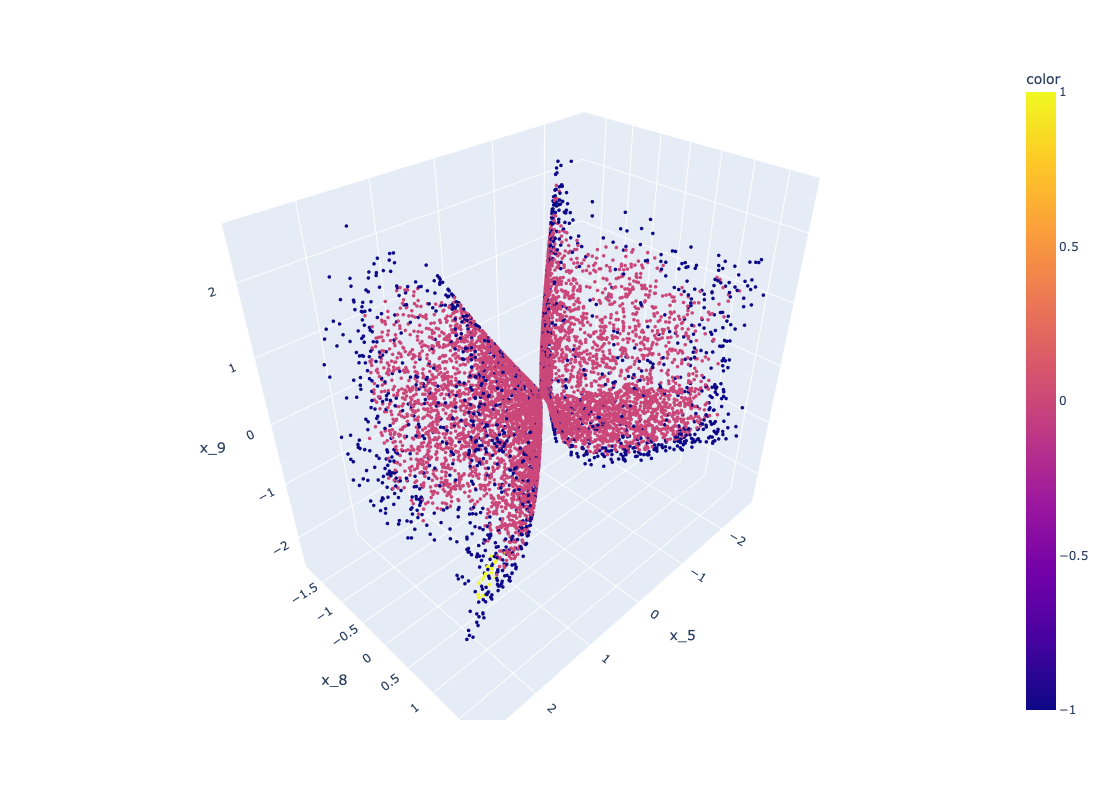

In [42]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

# Scatter plot
fig = px.scatter_3d(x=x_5d_deco[:,2], y=x_5d_deco[:,3], z=x_5d_deco[:,4], 
                    color=labels, labels={'x':'x_4', 'y':'x_8', 'z':'x_10'})
fig.update_layout(width=1000, height=800)
fig.update_traces(marker=dict(size=2)) 

fig.update_layout(scene=dict(xaxis_title='x_5', yaxis_title='x_8', zaxis_title='x_9'))
fig.show()